Text(0.5, 0, 'Period (h)')

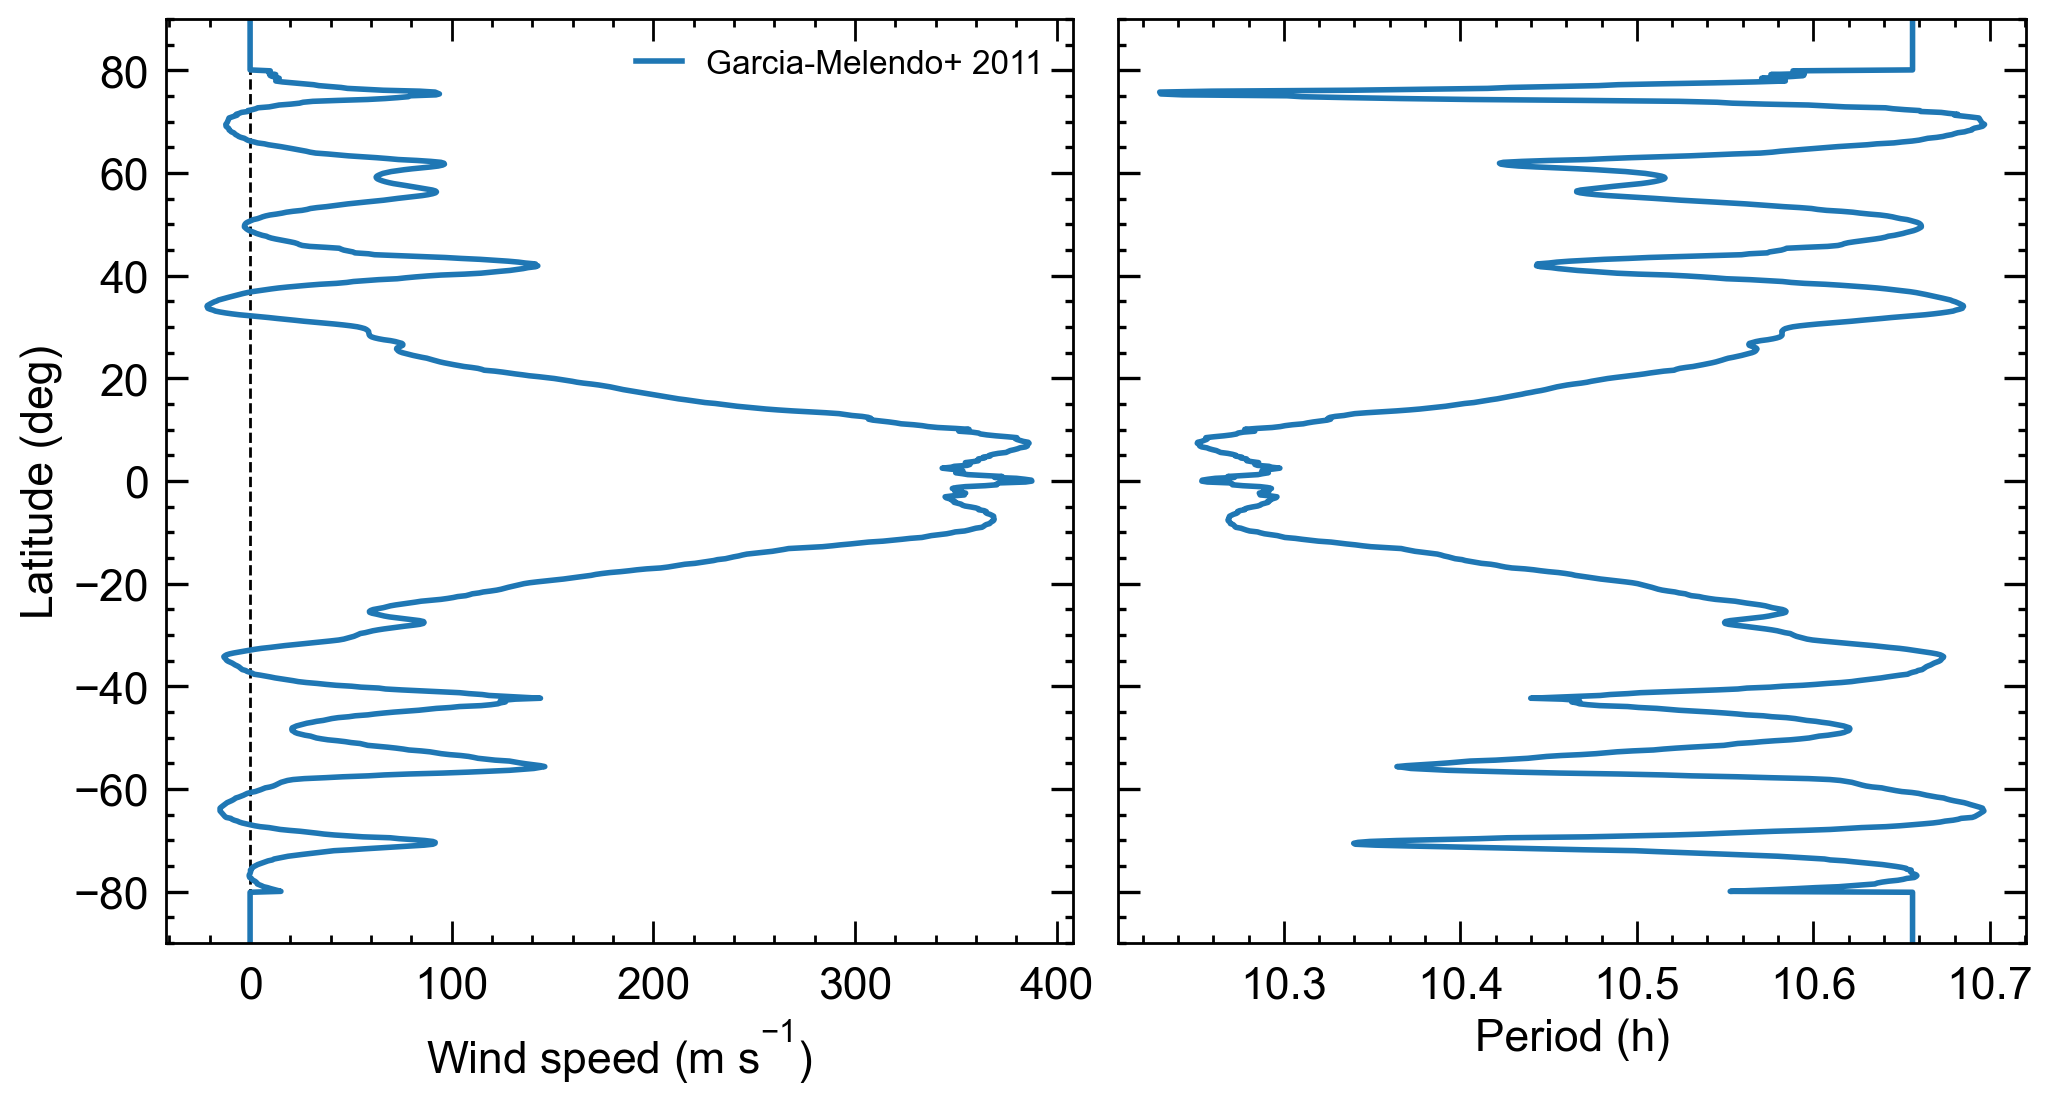

In [1]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
from scipy.integrate import trapezoid
from importlib import reload

import wind_profiles; reload(wind_profiles)
import geoid; reload(geoid)

# some constants for Saturn
r_ref = 60330e5 # reference radius for the Jn
gm = 37931207.7e15 # taken from Jacobson et al. 2006; not reported in Iess+2019 Table 1
jn = 16290.573e-6, -935.314e-6, 86.340e-6
p_rot_h_truth = 10. + 35. / 60 # no 'truth' for Saturn, of course

# 100-mbar radii from radio occultations, Lindal et al. 1985
occultation_radii = {
    'pioneer 11 ingress':(-9.7, 60138.0),
    'voyager 1 egress':(-2.4, 60353.5),
    'voyager 1 ingress':(-71.2, 54948.4),
    'voyager 2 ingress':(30.5, 58545.4),
    'voyager 2 egress':(-26.6, 58913.4),
}

phi = np.linspace(-np.pi / 2, np.pi / 2, 1001)
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'wspace':0.05})
ax[0].plot(1e-2 * wind_profiles.saturn_wind_profile_garciamelendo2011(phi), phi * 180 / np.pi, label='Garcia-Melendo+ 2011')

ax[0].set_xlabel('Wind speed (m s$^{-1}$)')
ax[0].set_ylabel('Latitude (deg)')
ax[0].legend(fontsize=12)
yl = -90, 90
ax[0].vlines(0, *yl, color='k', linestyle='--', linewidth=1, zorder=-1)
ax[0].set_ylim(*yl)

omega = wind_profiles.saturn_omega_tot_interpolant()
ax[1].plot(np.pi * 2 / omega(phi) / 3600, phi * 180 / np.pi)
ax[1].set_xlabel('Period (h)')

54445.7 4.2                       
rmse = 4.2 km
    period      r_pol       r_eq     h_mean
     10.50    54445.7    60365.4     -30.85
     10.58    54445.7    60365.4       7.47
     10.67    54445.7    60365.4      44.64


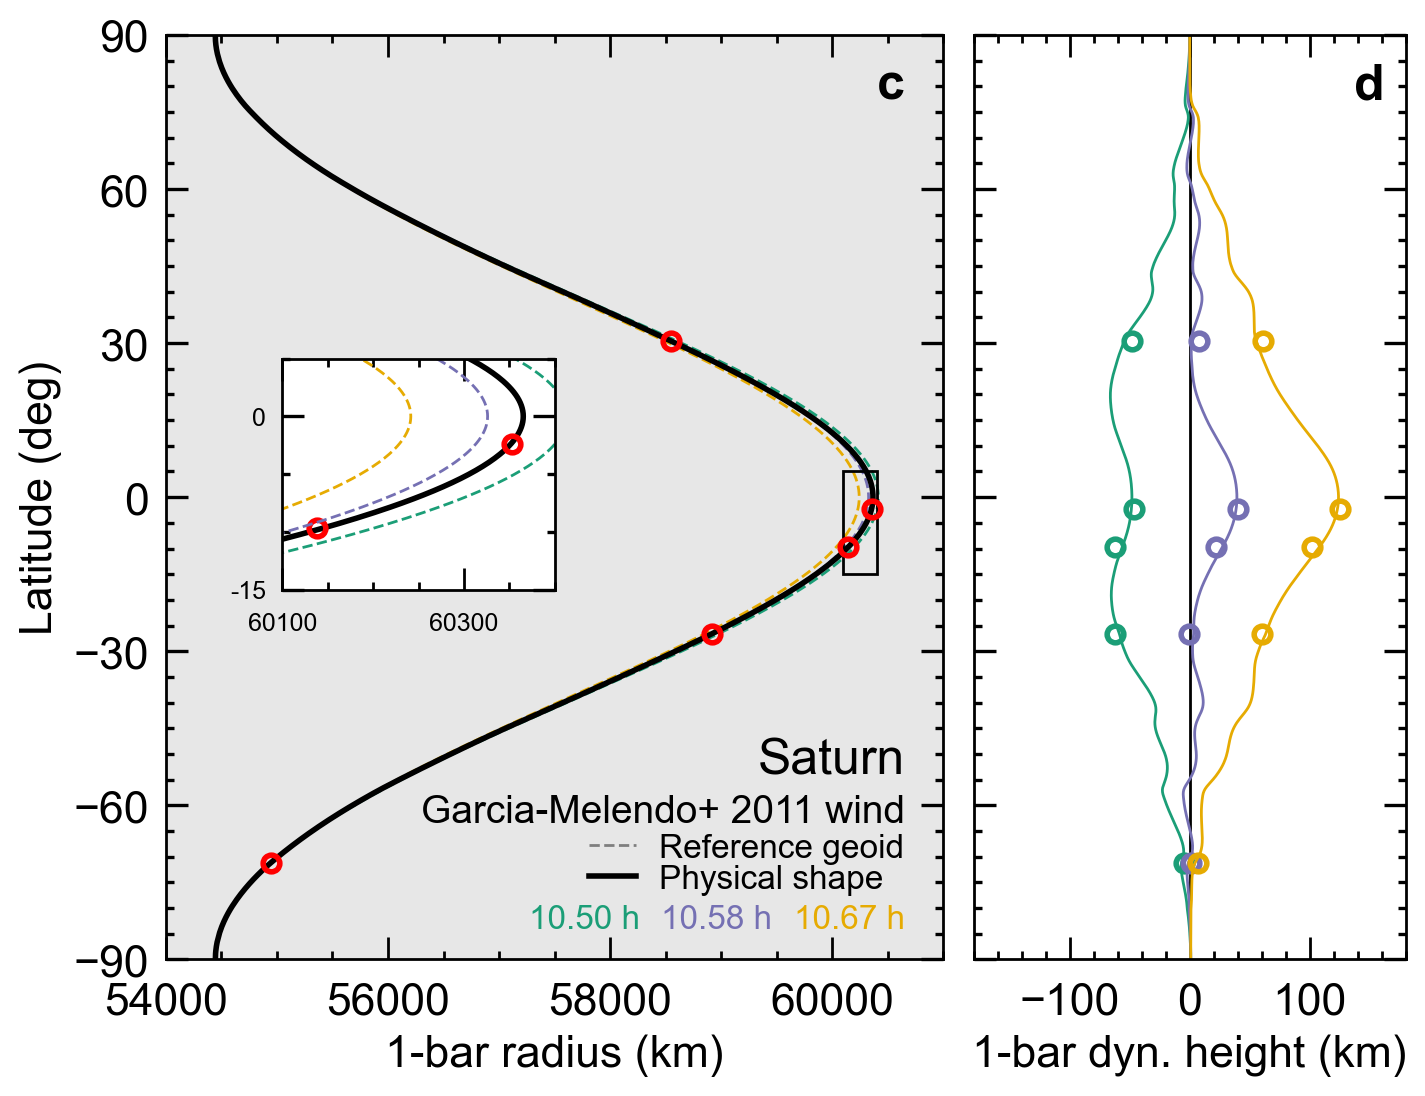

In [6]:
# main shape model plot for paper
def shape_plot(xlim=(54000, 61000), skip_inset_eq=False, inset_xlim=(60100, 60400)):    
    from matplotlib.patches import Rectangle
    fig, ax = plt.subplots(1, 2, figsize=(8, 6), gridspec_kw={'width_ratios':(9, 5), 'wspace':0.05})
    if not skip_inset_eq: # inset near equator
        inset_xlim = inset_xlim
        ax_inset_eq = ax[0].inset_axes([0.15, 0.4, 0.35, 0.25], xlim=inset_xlim, ylim=(-15, 5), xticklabels=[], yticklabels=[])
        ax[0].add_artist(Rectangle((inset_xlim[0], -15), inset_xlim[1]-inset_xlim[0], 20, facecolor='none', edgecolor='k', lw=1, zorder=2))
        xticks = np.linspace(inset_xlim[0], inset_xlim[1], 5)
        ax_inset_eq.set_xticks(xticks, minor=True)
        ax_inset_eq.set_xticks([inset_xlim[0], inset_xlim[1]], [inset_xlim[0], inset_xlim[1]], minor=False, fontsize=9)
        ax_inset_eq.set_yticks([-15, -10, -5, 0, 5], minor=True)
        ax_inset_eq.set_yticks([-15, 0], [-15, 0], minor=False, fontsize=9)
        ax_inset_eq.set_xlim(*inset_xlim)

    yl = -90, 90 # ax[1].get_ylim()
    ax[1].vlines(0, *yl, color='k', linewidth=1, zorder=-1)
    for z in ax:
        z.set_yticks(np.linspace(-90, 90, 7), minor=False)
        z.set_yticks(np.linspace(-90, 90, 37), minor=True)
        z.set_ylim(*yl)
    ax[1].tick_params(labelleft=False)
    ax[0].set_ylabel('Latitude (deg)')
    # ax[0].set_xlabel('100-mbar radius (km)')
    # ax[1].set_xlabel('100-mbar dyn. height (km)')
    ax[0].set_xlabel('1-bar radius (km)')
    ax[1].set_xlabel('1-bar dyn. height (km)')
    ax[0].set_facecolor('#e7e7e7')
    ax[0].set_xlim(*xlim)

    if skip_inset_eq:
        return ax
    else:
        return ax, ax_inset_eq

ax, ax_inset = shape_plot()
ax_inset.set_xticks(60100 + 50 * np.arange(7), minor=True)
ax_inset.set_xticks([60100, 60300], [60100, 60300], minor=False, fontsize=9)

reload(geoid)
reload(wind_profiles)
omega = wind_profiles.saturn_omega_tot_interpolant()
# omega = wind_profiles.saturn_omega_tot_interpolant_by_cylindrical_radius()

# find r_pol that minimizes rms radius error
from scipy.optimize import minimize
def rmse(x):
    r_pol = x[0] * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
    squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
    print(f'\r{r_pol*1e-5:.1f} {np.sqrt(np.mean(squared_errors)):.1f}', end=' '*20)
    return np.sqrt(np.mean(squared_errors))
# sol = minimize(rmse, np.array([5.5]), method='Powell', bounds=[[5, 6]], tol=1e-3)
sol = minimize(rmse, np.array([5.5]), method='Nelder-Mead', bounds=[[5, 6]])
print()
print(f'rmse = {sol.fun:.1f} km')
r_pol = sol.x[0] * 1e9

# get final shape for optimized r_pol
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

# reference geoids depend on rigid rotation; loop through them now
periods = p_rot_h_truth + np.array([-5./60, 0, +5/60.]) # +/- 5 minutes
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    color = plt.get_cmap('Dark2')(1. * ip / len(periods))

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.61 + 0.17 * ip, 0.06, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.037), fontsize=12)
ax[0].text(0.95, 0.19, 'Saturn', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.14, 'Garcia-Melendo+ 2011 wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)
ax[1].set_xlim(-180, 180)

for iax, c in enumerate('cd'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/saturn_optimize_rpol.pdf')

# rmse = 4.2 km
#     period      r_pol       r_eq     h_mean
#      10.50    54445.6    60365.3     -30.85
#      10.58    54445.6    60365.3       7.46
#      10.67    54445.6    60365.3      44.63


54445.5 3.9                       
rmse = 3.9 km
    period      r_pol       r_eq     h_mean
     10.50    54445.5    60365.7     -30.65
     10.58    54445.5    60365.7       7.66
     10.67    54445.5    60365.7      44.83


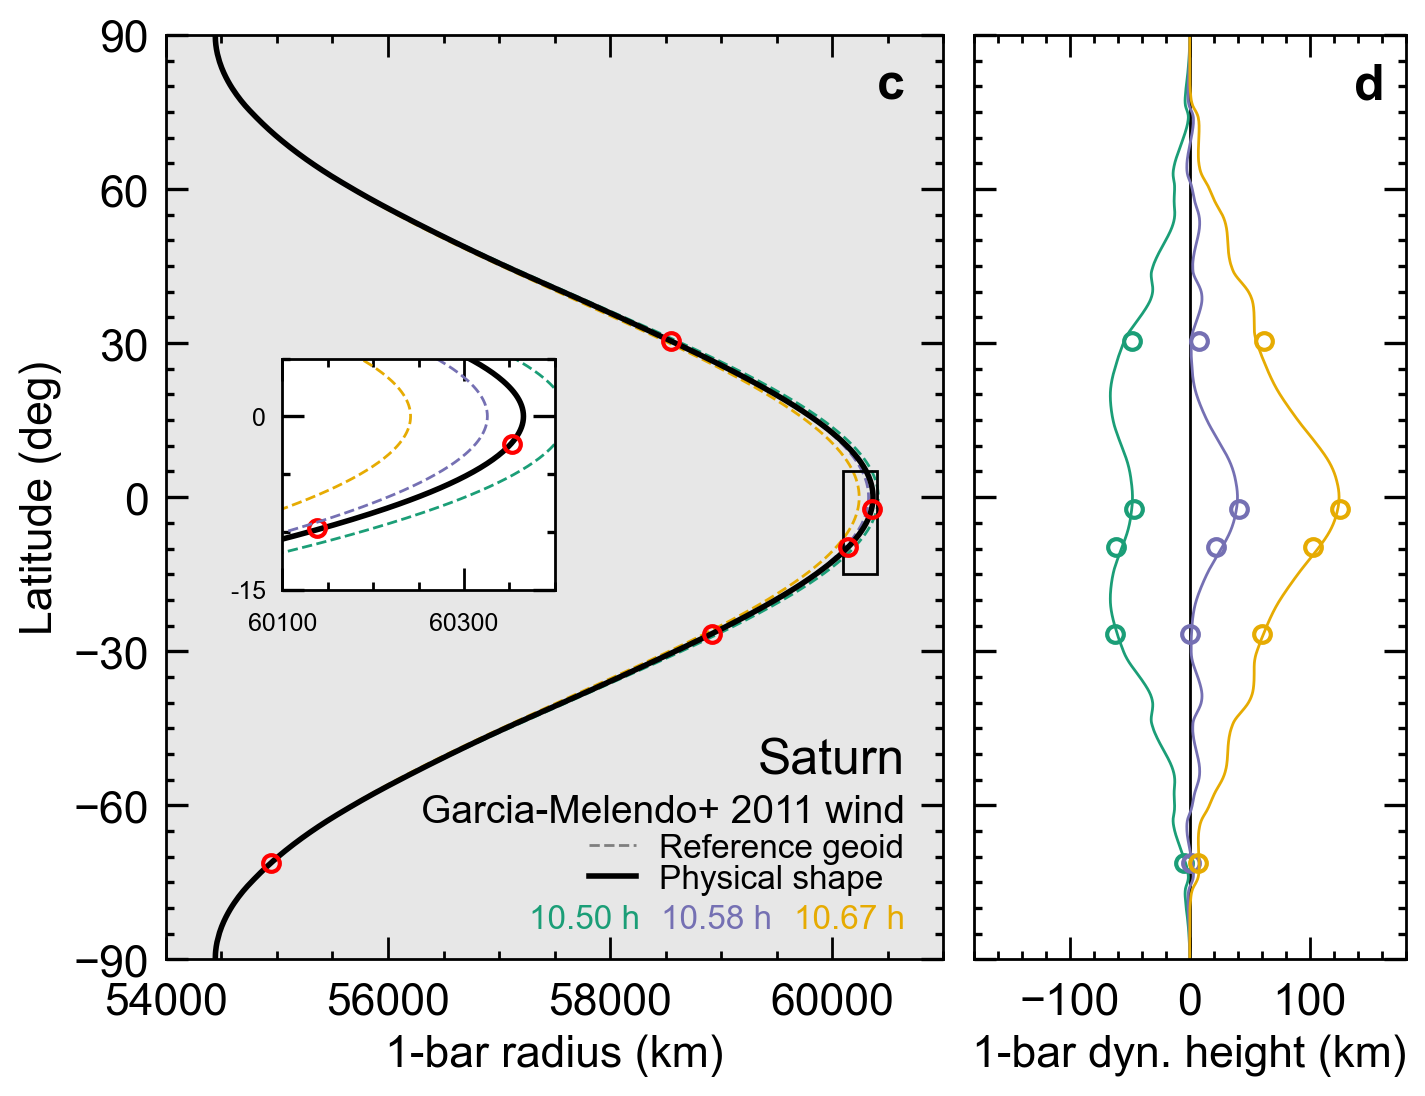

In [3]:
# same but use version of omega function that keeps omega fixed as a function of distance from rotation axis
ax, ax_inset = shape_plot()
ax_inset.set_xticks(60100 + 50 * np.arange(7), minor=True)
ax_inset.set_xticks([60100, 60300], [60100, 60300], minor=False, fontsize=9)

reload(geoid)
reload(wind_profiles)
# omega = wind_profiles.saturn_omega_tot_interpolant()
omega = wind_profiles.saturn_omega_tot_interpolant_by_cylindrical_radius()

# find r_pol that minimizes rms radius error
from scipy.optimize import minimize
def rmse(x):
    r_pol = x[0] * 1e9
    g = geoid.geoid_barotropic(r_pol, jn, r_ref, gm, omega=omega) # note, no presumed rigid rotation period enters the calculation
    squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
    print(f'\r{r_pol*1e-5:.1f} {np.sqrt(np.mean(squared_errors)):.1f}', end=' '*20)
    return np.sqrt(np.mean(squared_errors))
sol = minimize(rmse, np.array([5.5]), method='Powell', bounds=[[5, 6]], tol=1e-2)
print()
print(f'rmse = {sol.fun:.1f} km')
r_pol = sol.x[0] * 1e9

# get final shape for optimized r_pol
g = geoid.geoid_barotropic(r_pol, jn, r_ref, gm, omega=omega)

# ax, ax_inset_eq, ax_inset_pol = plot(g, color='k', suppress_legend=True, skip_inset_pol=False, width_ratios=(9, 5), xlim_inset_pol=(24970, 24980))
ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=1.5)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=1.5)

# reference geoids depend on rigid rotation; loop through them now
periods = p_rot_h_truth + np.array([-5./60, 0, +5/60.]) # +/- 5 minutes
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")
for ip, p_rot_h in enumerate(periods):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid_barotropic(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    color = plt.get_cmap('Dark2')(1. * ip / len(periods))

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=1.5)

    ax[0].text(0.61 + 0.17 * ip, 0.06, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.037), fontsize=12)
ax[0].text(0.95, 0.19, 'Saturn', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.14, 'Garcia-Melendo+ 2011 wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)
ax[1].set_xlim(-180, 180)

for iax, c in enumerate('cd'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/saturn_optimize_rpol_omega_by_cylindrical_radius.pdf')


rmse = 4.2 km
    period      r_pol       r_eq     h_mean
     10.58    54445.6    60365.3       7.46


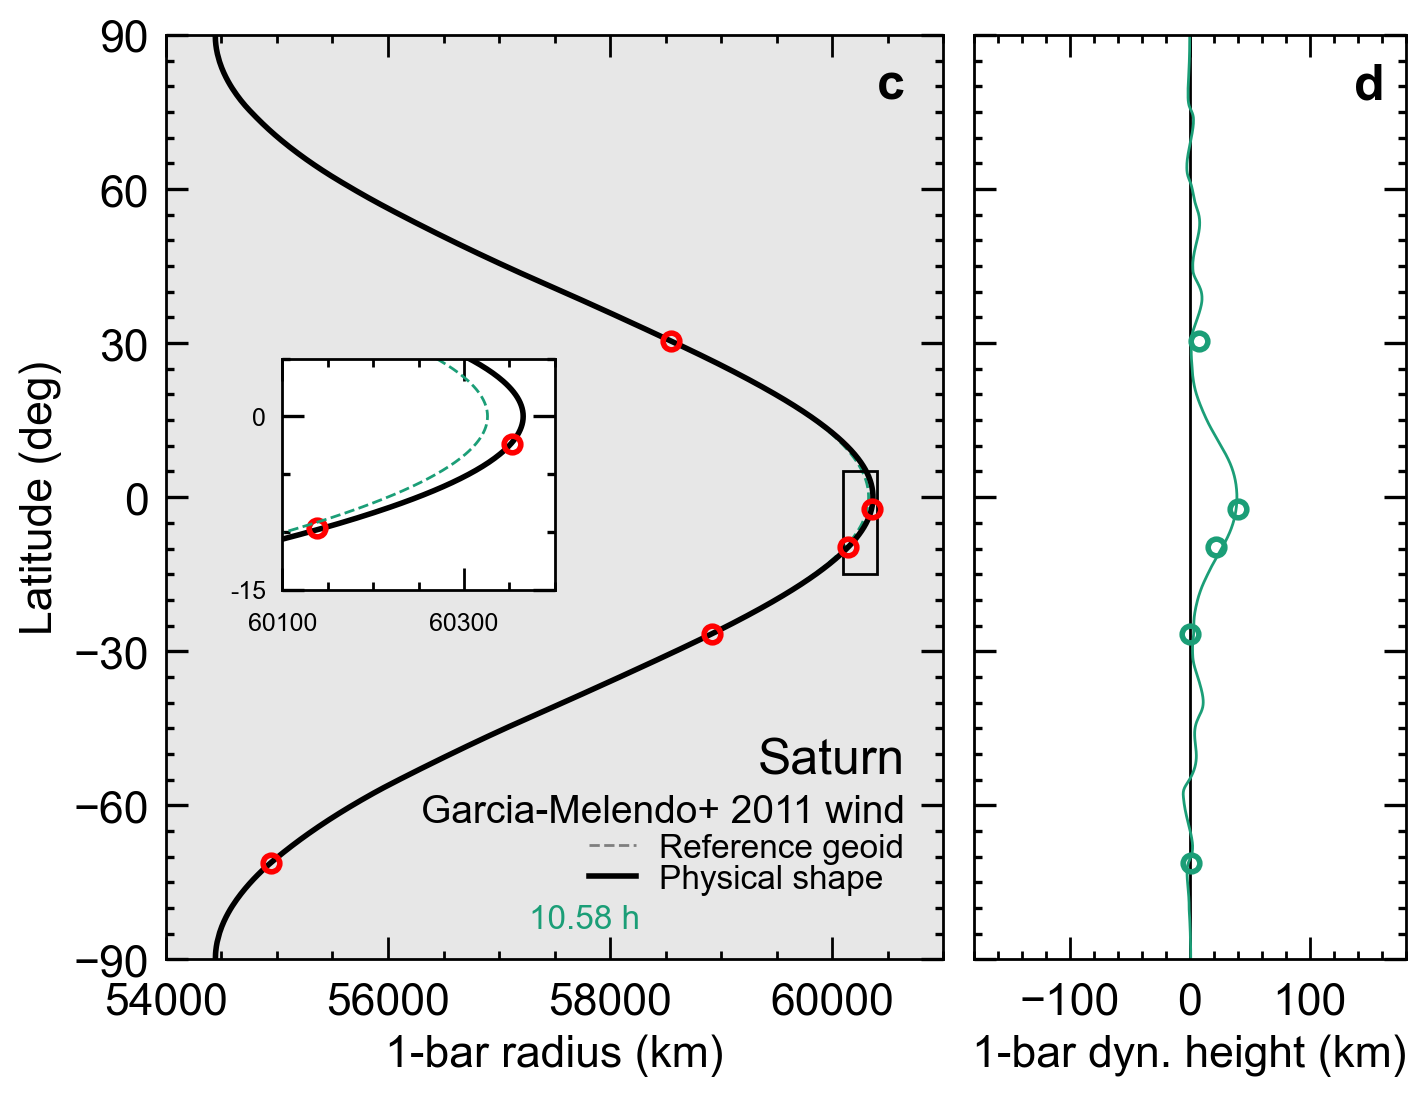

In [4]:
# repeat main saturn model to save output

ax, ax_inset = shape_plot()
ax_inset.set_xticks(60100 + 50 * np.arange(7), minor=True)
ax_inset.set_xticks([60100, 60300], [60100, 60300], minor=False, fontsize=9)

reload(geoid)
reload(wind_profiles)
omega = wind_profiles.saturn_omega_tot_interpolant()

# find r_pol that minimizes rms radius error
from scipy.optimize import minimize
def rmse(x):
    r_pol = x[0] * 1e9
    g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)
    squared_errors = np.array([ (_r - np.interp(_lat, g.lat[::-1], 1e-5 * g.r[::-1])) ** 2 for occ, (_lat, _r) in occultation_radii.items()])
    return np.sqrt(np.mean(squared_errors))
sol = minimize(rmse, np.array([5.5]), method='Powell', bounds=[[5, 6]], tol=1e-2)
print(f'rmse = {sol.fun:.1f} km')
r_pol = sol.x[0] * 1e9

# get final shape for optimized r_pol
g = geoid.geoid(r_pol, jn, r_ref, gm, omega=omega)

ax[0].plot(1e-5 * g.r, g.lat, 'k-')
ax_inset.plot(1e-5 * g.r, g.lat, 'k-')
for occ, (latitude, radius) in occultation_radii.items():
    ax[0]   .plot(radius, latitude, 'ro', mfc='none', mew=2)
    ax_inset.plot(radius, latitude, 'ro', mfc='none', mew=2)

# compute reference geoid
print(f"{'period':>10} {'r_pol':>10} {'r_eq':>10} {'h_mean':>10}")
for ip, p_rot_h in enumerate((p_rot_h_truth,)):
    
    r_pol = g.r[0]
    r_eq = g.r[len(g.mu) // 2]
    g_ref = geoid.geoid(r_pol, jn, r_ref, gm, omega=np.pi*2/(p_rot_h*3600))
    
    color = plt.get_cmap('Dark2')(1. * ip / len(periods))

    ax[0].plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1, zorder=0)
    ax_inset.plot(1e-5 * g_ref.r, g.lat, '--', color=color, lw=1)

    h = g.r - g_ref.r
    h_mean = -1. / 180 * trapezoid(h, x=g.lat)

    ax[1].plot(1e-5 * h, g.lat, '-', color=color, lw=1)
    for occ, (latitude, radius) in occultation_radii.items():
        ax[1].plot(np.interp(latitude, g.lat[::-1], radius - 1e-5 * g_ref.r[::-1]), latitude, 'o', color=color, mfc='none', mew=2)

    ax[0].text(0.61 + 0.17 * ip, 0.06, f'{p_rot_h:.2f} h', color=color, fontsize=12, ha='right', va='top', transform=ax[0].transAxes)
    print(f'{p_rot_h:10.2f} {1e-5*r_pol:10.1f} {1e-5*r_eq:10.1f} {1e-5 * h_mean:10.2f}')


ax[0].plot([], '--', color='tab:grey', lw=1, label='Reference geoid')
# ax[0].plot([], 'k-', lw=1, label='Isobaric surface')
ax[0].plot([], 'k-', label='Physical shape')
ax[0].legend(loc=4, bbox_to_anchor=(0.988, 0.037), fontsize=12)
ax[0].text(0.95, 0.19, 'Saturn', ha='right', va='bottom', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.95, 0.14, 'Garcia-Melendo+ 2011 wind', ha='right', va='bottom', fontsize=14, transform=ax[0].transAxes)
ax[1].set_xlim(-180, 180)

for iax, c in enumerate('cd'):
    ax[iax].text(0.95, 0.97, c, weight='bold', fontsize=18, ha='right', va='top', transform=ax[iax].transAxes)



# save geoid objects in pickled python dictionaries
# import dill as pickle
import pickle
with open('models/geoid_objects/saturn.pkl', 'wb') as fw:
    pickle.dump({'geoid':g, 'reference_geoid':g_ref}, fw)

# save full model output to plaintext
outfile = 'models/saturn_model.txt'
header  = "detailed model output for Saturn's 100-mbar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'this is the isobaric shape model at 100 mbar; see saturn_model_reference_geoid.txt for an accompanying reference geoid rotating rigidly at 10h 35m period.\n'
header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
fmt = '%16.10f'
names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
for name in names:
    header += f"{name:>16} "
data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

outfile = 'models/saturn_model_reference_geoid.txt'
header  = "detailed model output for Saturn's 100-mbar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += "this model is the reference geoid assumed to be rigidly rotating with a period 10h 35m.\n"
header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
fmt = '%16.10f'
names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
for name in names:
    header += f"{name:>16} "
data = np.array([g_ref.mu, g_ref.phi, g_ref.lat, g_ref.planetographic_latitude, g_ref.psi, g_ref.omega, 1e-5 * g_ref.r]).T
np.savetxt(outfile, data, fmt=fmt, header=header, comments='')
